# Ensemble Learning

### 1. Can we use Bagging for regression problems?
Yes. Bagging (Bootstrap Aggregating) can be used for both classification and regression. In regression, the final prediction is typically the average of the predictions made by all individual base models.

### 2. What is the difference between multiple model training and single model training?
Single model training involves fitting one algorithm (like one Decision Tree) to the data. Multiple model training involves training several models (either of the same type or different types) and combining their outputs to improve overall performance and robustness.

### 3. Explain the concept of feature randomness in Random Forest.
In Random Forest, feature randomness (or "feature bagging") means that when splitting a node, the algorithm only considers a random subset of the available features rather than all of them. This ensures that the individual trees are decorrelated, making the ensemble more robust.

### 4. What is OOB (Out-of-Bag) Score?
When using bootstrap sampling, some data points are not selected for training a particular base model; these are "Out-of-Bag" samples. The OOB score is the performance measure of the model calculated using these unseen samples, acting as a built-in cross-validation.

### 5. How can you measure the importance of features in a Random Forest model?
Feature importance is measured by calculating the total reduction in the criterion (like Gini impurity or Mean Squared Error) brought by a specific feature across all trees in the forest. Features that frequently appear near the top of the trees and cause significant error reduction are considered more important.

### 6. Explain the working principle of a Bagging Classifier.
A Bagging Classifier works by creating multiple subsets of the original training data using bootstrap sampling (sampling with replacement). A base classifier is trained on each subset, and the final classification is determined by a majority vote of all the individual models.

### 7. How do you evaluate a Bagging Classifier's performance?
Performance is evaluated using standard classification metrics such as accuracy, precision, recall, F1-score, and the ROC-AUC score. It can also be evaluated using the OOB score or cross-validation.

### 8. How does a Bagging Regressor work?
Similar to the classifier, it trains multiple regressors on different bootstrap samples of the data. However, instead of voting, the final output is the numerical average of the predictions from all individual regressors.

### 9. What is the main advantage of ensemble techniques?
The main advantage is improved predictive performance and stability. They reduce the variance (overfitting) and/or bias of individual models, often leading to more accurate and generalized results.

### 10. What is the main challenge of ensemble methods?
The main challenges include increased computational cost (training multiple models takes more time and memory) and reduced interpretability, as it is harder to explain the logic of a thousand combined models compared to a single one.

### 11. Explain the key idea behind ensemble techniques.
The key idea is the "wisdom of the crowd": combining multiple weak or diverse models to create a single "strong learner" that performs better than any of the individual components.

### 12. What is a Random Forest Classifier?
A Random Forest Classifier is an ensemble of many Decision Trees, trained using both bootstrap sampling and feature randomness. The final class is decided by the majority vote of the trees.

### 13. What are the main types of ensemble techniques?
The main types include:
* **Bagging** (e.g., Random Forest)
* **Boosting** (e.g., AdaBoost, Gradient Boosting)
* **Stacking** (combining different model types using a meta-learner)

### 14. What is ensemble learning in machine learning?
Ensemble learning is a process where multiple models (base learners) are strategically generated and combined to solve a particular computational intelligence problem.

### 15. When should we avoid using ensemble methods?
They should be avoided when the base model is already performing optimally, when interpretability is the highest priority, or when computational resources (time/memory) are strictly limited.

### 16. How does Bagging help in reducing overfitting?
Bagging reduces overfitting by decreasing the variance of the model. Because each model is trained on a slightly different subset of data and their results are averaged, the impact of noise or outliers in the training set is minimized.

### 17. Why is Random Forest better than a single Decision Tree?
A single Decision Tree is prone to high variance and can easily overfit the training data. Random Forest averages the results of many trees (which are decorrelated via feature randomness), resulting in a more stable and accurate model that generalizes better to new data.

### 18. What is the role of bootstrap sampling in Bagging?
Bootstrap sampling involves creating random datasets by sampling with replacement from the original data. This ensures that each base model in the ensemble sees a slightly different version of the data, which creates the diversity necessary for the ensemble to be effective.

### 19. What are some real-world applications of ensemble techniques?
Ensemble techniques are used in various fields including credit scoring, medical diagnosis, stock market prediction, and recommendation systems.

### 20. What is the difference between Bagging and Boosting?
* **Bagging:** Models are trained in parallel, each on a random subset of data. The goal is primarily to reduce variance.
* **Boosting:** Models are trained sequentially. Each new model attempts to correct the errors made by the previous models. The goal is primarily to reduce bias.

### 21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

In [1]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bagging Classifier
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bag_clf.fit(X_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, bag_clf.predict(X_test))}")

Accuracy: 0.9


### 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

In [2]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=42)
bag_reg.fit(X_train, y_train)

print(f"MSE: {mean_squared_error(y_test, bag_reg.predict(X_test))}")

MSE: 2626.20948800766


### 23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(data.data, data.target)

importance = pd.Series(rf_clf.feature_importances_, index=data.feature_names)
print(importance.sort_values(ascending=False))

worst area                 0.139357
worst concave points       0.132225
mean concave points        0.107046
worst radius               0.082848
worst perimeter            0.080850
mean perimeter             0.067990
mean concavity             0.066917
mean area                  0.060462
worst concavity            0.037339
mean radius                0.034843
area error                 0.029553
worst compactness          0.019864
worst texture              0.017485
mean texture               0.015225
radius error               0.014264
worst smoothness           0.012232
mean compactness           0.011597
perimeter error            0.010085
worst symmetry             0.008179
mean smoothness            0.007958
fractal dimension error    0.005942
concavity error            0.005820
compactness error          0.005612
smoothness error           0.004722
worst fractal dimension    0.004497
concave points error       0.003760
texture error              0.003744
symmetry error             0

### 24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
dt_reg = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)

print(f"RF MSE: {mean_squared_error(y_test, rf_reg.predict(X_test))}")
print(f"DT MSE: {mean_squared_error(y_test, dt_reg.predict(X_test))}")

RF MSE: 2618.1999220227403
DT MSE: 6418.515788751743


### 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

In [7]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# Generate classification data instead of regression data
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now the Classifier will work
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f"OOB Score: {rf_oob.oob_score_}")

OOB Score: 0.89


### 26. Train a Bagging Classifier using SVM as a base estimator and print accuracy.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Re-generate CLASSIFICATION data (discrete labels)
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the Bagging Classifier using SVM [cite: 35]
bag_svc = BaggingClassifier(estimator=SVC(), n_estimators=10, random_state=42)
bag_svc.fit(X_train, y_train)

print(f"Accuracy (SVM Bagging): {bag_svc.score(X_test, y_test)}")

Accuracy (SVM Bagging): 0.87


### 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.

In [9]:
for n in [10, 50, 100, 200]:
    clf = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    print(f"Trees: {n}, Accuracy: {clf.score(X_test, y_test)}")

Trees: 10, Accuracy: 0.855
Trees: 50, Accuracy: 0.88
Trees: 100, Accuracy: 0.9
Trees: 200, Accuracy: 0.895


### 28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

bag_lr = BaggingClassifier(estimator=LogisticRegression(), n_estimators=50, random_state=42)
bag_lr.fit(X_train, y_train)
probs = bag_lr.predict_proba(X_test)[:, 1]
print(f"AUC Score: {roc_auc_score(y_test, probs)}")

AUC Score: 0.9219173952366597


### 29. Train a Random Forest Regressor and analyze feature importance scores.

In [11]:
rf_reg_imp = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
print(f"Feature Importances: {rf_reg_imp.feature_importances_}")

Feature Importances: [0.00871783 0.0153229  0.01734636 0.01171458 0.01056074 0.62262553
 0.01565511 0.01408617 0.01224897 0.01312505 0.0088828  0.02392149
 0.01674666 0.01036746 0.12081239 0.01434272 0.0147293  0.01346628
 0.02271187 0.0126158 ]


### 30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [12]:
# Comparison of two ensemble types
bag_acc = BaggingClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)
rf_acc = RandomForestClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)

print(f"Bagging Accuracy: {bag_acc}")
print(f"Random Forest Accuracy: {rf_acc}")

Bagging Accuracy: 0.885
Random Forest Accuracy: 0.9


### 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV. 

In [13]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=3)
grid.fit(X_train, y_train)
print(f"Best Params: {grid.best_params_}")

Best Params: {'max_depth': 10, 'n_estimators': 100}


### 32. Train a Bagging Regressor with different numbers of base estimators and compare performance.

In [14]:
for n in [10, 50, 100]:
    reg = BaggingRegressor(n_estimators=n, random_state=42).fit(X_train, y_train)
    print(f"Estimators: {n}, MSE: {mean_squared_error(y_test, reg.predict(X_test))}")

Estimators: 10, MSE: 0.09740000000000001
Estimators: 50, MSE: 0.08930199999999999
Estimators: 100, MSE: 0.0862045


### 33. Train a Random Forest Classifier and analyze misclassified samples.

In [15]:
rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
preds = rf_clf.predict(X_test)
misclassified = X_test[y_test != preds]
print(f"Number of misclassified samples: {len(misclassified)}")

Number of misclassified samples: 20


### 34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

In [16]:
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)
bag = BaggingClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)
print(f"Single Tree: {dt}, Bagging: {bag}")

Single Tree: 0.875, Bagging: 0.885


### 35. Train a Random Forest Classifier and visualize the confusion matrix.

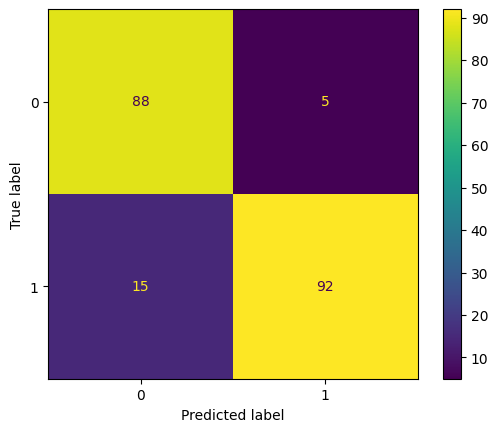

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
cm = confusion_matrix(y_test, rf_clf.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.show()

### 36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

In [18]:
from sklearn.ensemble import StackingClassifier

estimators = [('dt', DecisionTreeClassifier()), ('svc', SVC(probability=True))]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)
print(f"Stacking Accuracy: {stack.score(X_test, y_test)}")

Stacking Accuracy: 0.87


### 37. Train a Random Forest Classifier and print the top 5 most important features.

In [19]:
rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
importances = pd.Series(rf_clf.feature_importances_)
print(f"Top 5 Features:\n{importances.sort_values(ascending=False).head(5)}")

Top 5 Features:
5     0.363134
18    0.177252
1     0.101820
14    0.075575
11    0.025690
dtype: float64


### 38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.

In [20]:
from sklearn.metrics import classification_report

bag_clf = BaggingClassifier(random_state=42).fit(X_train, y_train)
print(classification_report(y_test, bag_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89        93
           1       0.96      0.82      0.88       107

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



### 39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

In [21]:
for depth in [1, 5, 10, None]:
    clf = RandomForestClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    print(f"Max Depth: {depth}, Accuracy: {clf.score(X_test, y_test)}")

Max Depth: 1, Accuracy: 0.86
Max Depth: 5, Accuracy: 0.88
Max Depth: 10, Accuracy: 0.885
Max Depth: None, Accuracy: 0.9


### 40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.

In [22]:
from sklearn.neighbors import KNeighborsRegressor

bag_dt = BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42).fit(X_train, y_train)
bag_kn = BaggingRegressor(estimator=KNeighborsRegressor(), random_state=42).fit(X_train, y_train)
print(f"DT Bagging MSE: {mean_squared_error(y_test, bag_dt.predict(X_test))}")
print(f"KNN Bagging MSE: {mean_squared_error(y_test, bag_kn.predict(X_test))}")

DT Bagging MSE: 0.09740000000000001
KNN Bagging MSE: 0.143162


### 41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

In [23]:
rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print(f"ROC-AUC: {roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1])}")

ROC-AUC: 0.9379459350819013


### 42. Train a Bagging Classifier and evaluate its performance using cross-validation.

In [24]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(BaggingClassifier(), X, y, cv=5)
print(f"Cross-Val Mean Accuracy: {scores.mean()}")

Cross-Val Mean Accuracy: 0.893


### 43. Train a Random Forest Classifier and plot the Precision-Recall curve.

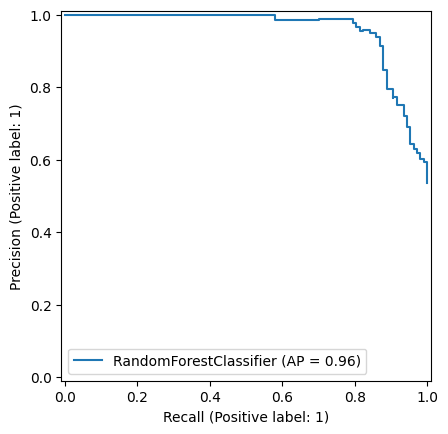

In [25]:
from sklearn.metrics import PrecisionRecallDisplay
rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
PrecisionRecallDisplay.from_estimator(rf_clf, X_test, y_test)
plt.show()

### 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

In [26]:
estimators = [('rf', RandomForestClassifier(random_state=42))]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)
print(f"Stacking (RF+LR) Accuracy: {stack.score(X_test, y_test)}")

Stacking (RF+LR) Accuracy: 0.9


### 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [27]:
for samples in [0.5, 0.7, 1.0]:
    reg = BaggingRegressor(max_samples=samples, random_state=42).fit(X_train, y_train)
    print(f"Max Samples: {samples}, MSE: {mean_squared_error(y_test, reg.predict(X_test))}")

Max Samples: 0.5, MSE: 0.10554999999999999
Max Samples: 0.7, MSE: 0.10385000000000001
Max Samples: 1.0, MSE: 0.09740000000000001
